In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv
/kaggle/input/competitions/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv


# 1. Setup and load data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [25]:
train_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv", index_col=0)
test_data = pd.read_csv("/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv", index_col=0)
data_dict = pd.read_excel("/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls")

# 2. Data overview

In [26]:
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Variable Name,Description,Type
1,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
2,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
3,age,Age of borrower in years,integer
4,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
5,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
6,MonthlyIncome,Monthly income,real
7,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
8,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
9,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer


In [27]:
train_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# 3. Data quality checking

In [28]:
train_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Từ bảng describe, ta có thể chú ý vài điều:
- Dataset mất cân bằng nhãn, do mean = 0.06 (6.7% khách hàng có label = 1)
- Biến "RevolvingUtilizationOfUnsecuredLines" có giá trị bất thường, do max = 50708. Bình thường biến nằm trong khoảng [0, 1]
- age có giá trị bất thường = 0
- "DebtRatio" có giá trị bất thường, do tỷ lệ chỉ nằm trong khoảng [0, 1]
- Số lần trễ hạn (NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse) có giá trị bất thường 98
- Missing values: biến MonthlyIncome và biến NumberOfDependents

In [29]:
train_data.duplicated().sum()

np.int64(609)

### Một vài vấn đề của bộ dữ liệu
* Dataset mất cân bằng nhãn
* Nhiều biến có giá trị bất thường: RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse
* Có 2 biến có missing values: MonthlyIncome, NumberOfDependents
* Dữ liệu tập train có những dòng trùng lặp

# 4. Univariate Analysis

### Phân tích nhãn

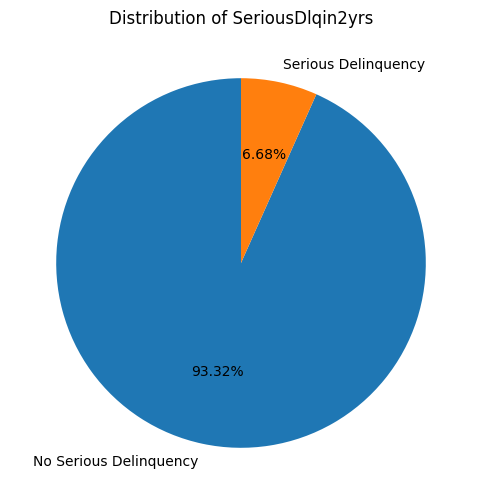

In [30]:
target_counts = train_data["SeriousDlqin2yrs"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    target_counts,
    labels=["No Serious Delinquency", "Serious Delinquency"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Distribution of SeriousDlqin2yrs")
plt.show()

Dataset bị mất cân bằng nghiêm trọng, chỉ có khoảng 6.68% khách hàng là có nhãn = 1

### Phân tích phân phối của từng biến

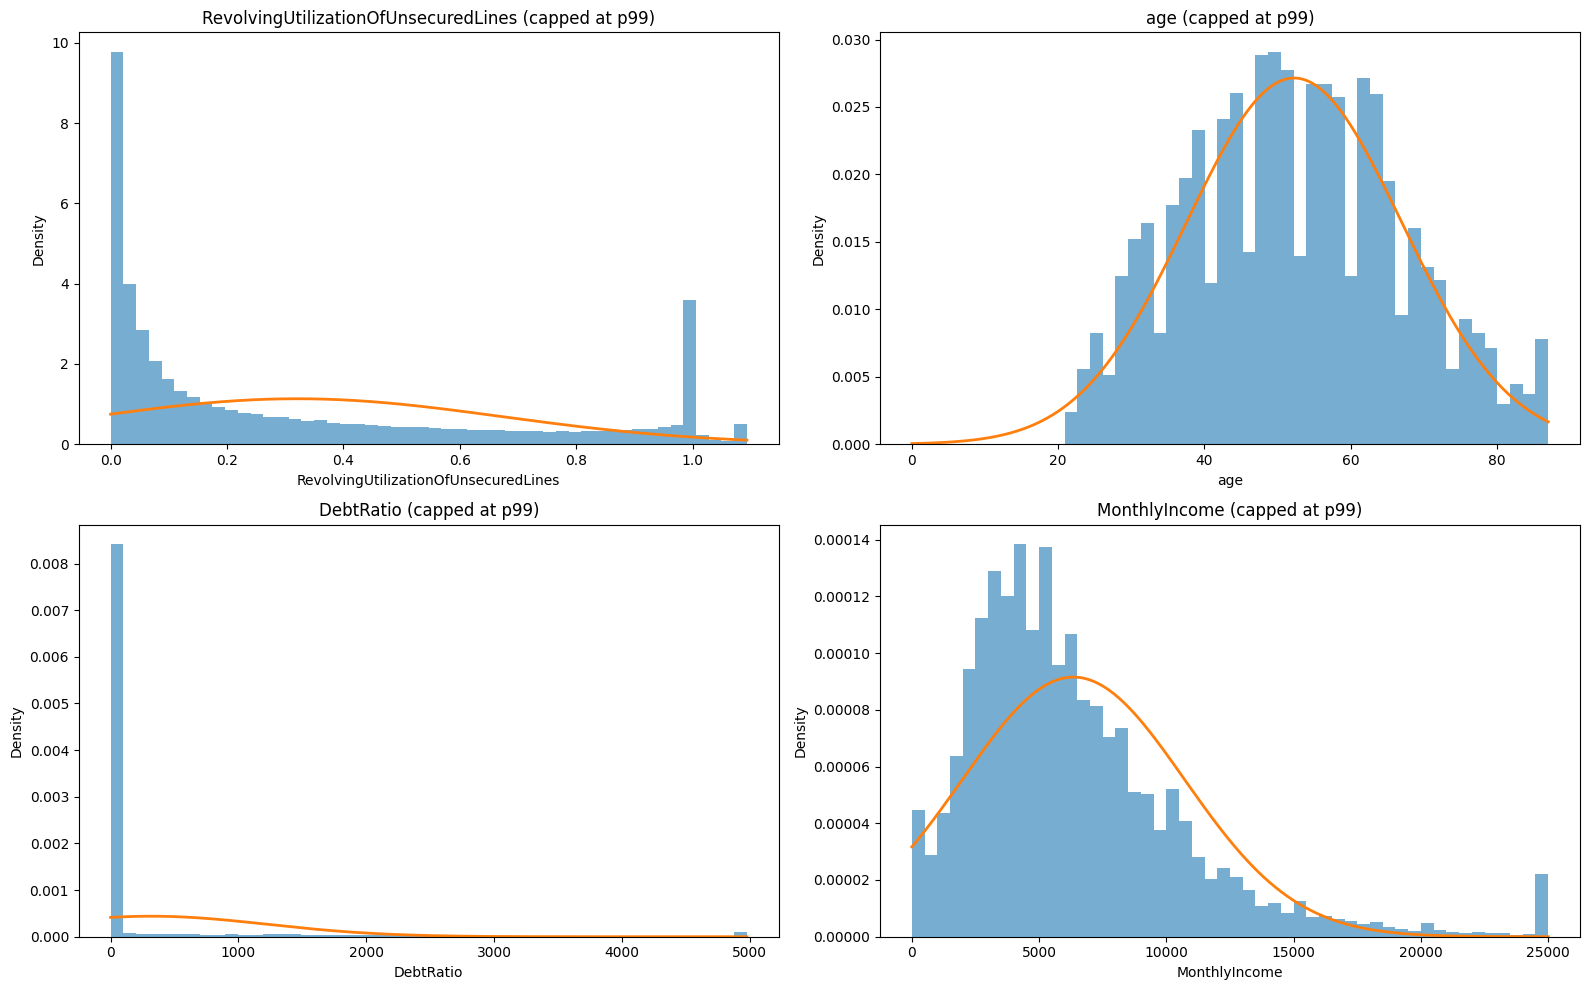

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

continuous_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(continuous_cols, 1):
    data = train_data[col].dropna()

    # Cap tại p99
    p99 = data.quantile(0.99)
    data_capped = data.clip(upper=p99)

    # Tính mean và std trên dữ liệu đã cap
    mu = data_capped.mean()
    sigma = data_capped.std()

    plt.subplot(2, 2, i)

    # Histogram dạng density
    plt.hist(data_capped, bins=50, density=True, alpha=0.6)

    # Normal curve
    x = np.linspace(data_capped.min(), data_capped.max(), 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, linewidth=2)

    plt.title(f"{col} (capped at p99)")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

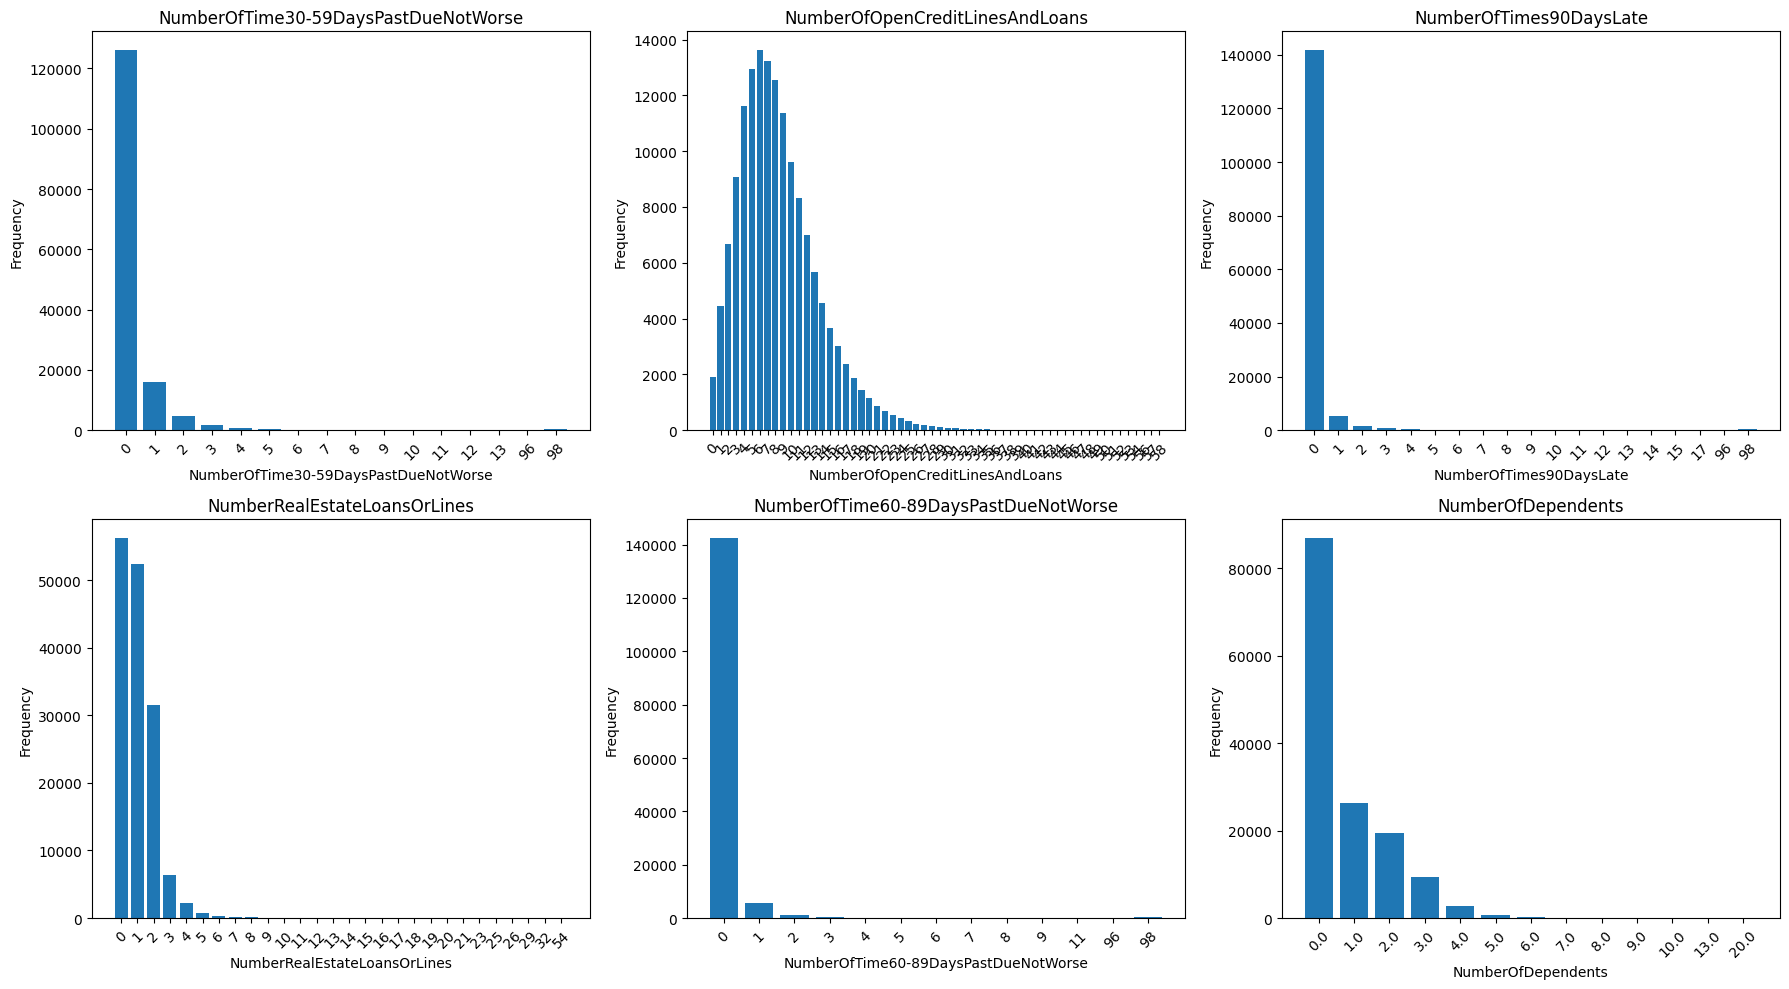

In [34]:
import matplotlib.pyplot as plt

discrete_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(discrete_cols, 1):
    data = train_data[col].dropna()

    value_counts = data.value_counts().sort_index()

    plt.subplot(2, 3, i)

    plt.bar(
        value_counts.index.astype(str),
        value_counts.values
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Từ các biểu đồ histogram, ta có thể nhìn thấy hầu hết các biến đều bị lệch phải, ngoại trừ biến age có phân phối gần chuẩn

### Kiểm tra outlier của các biến

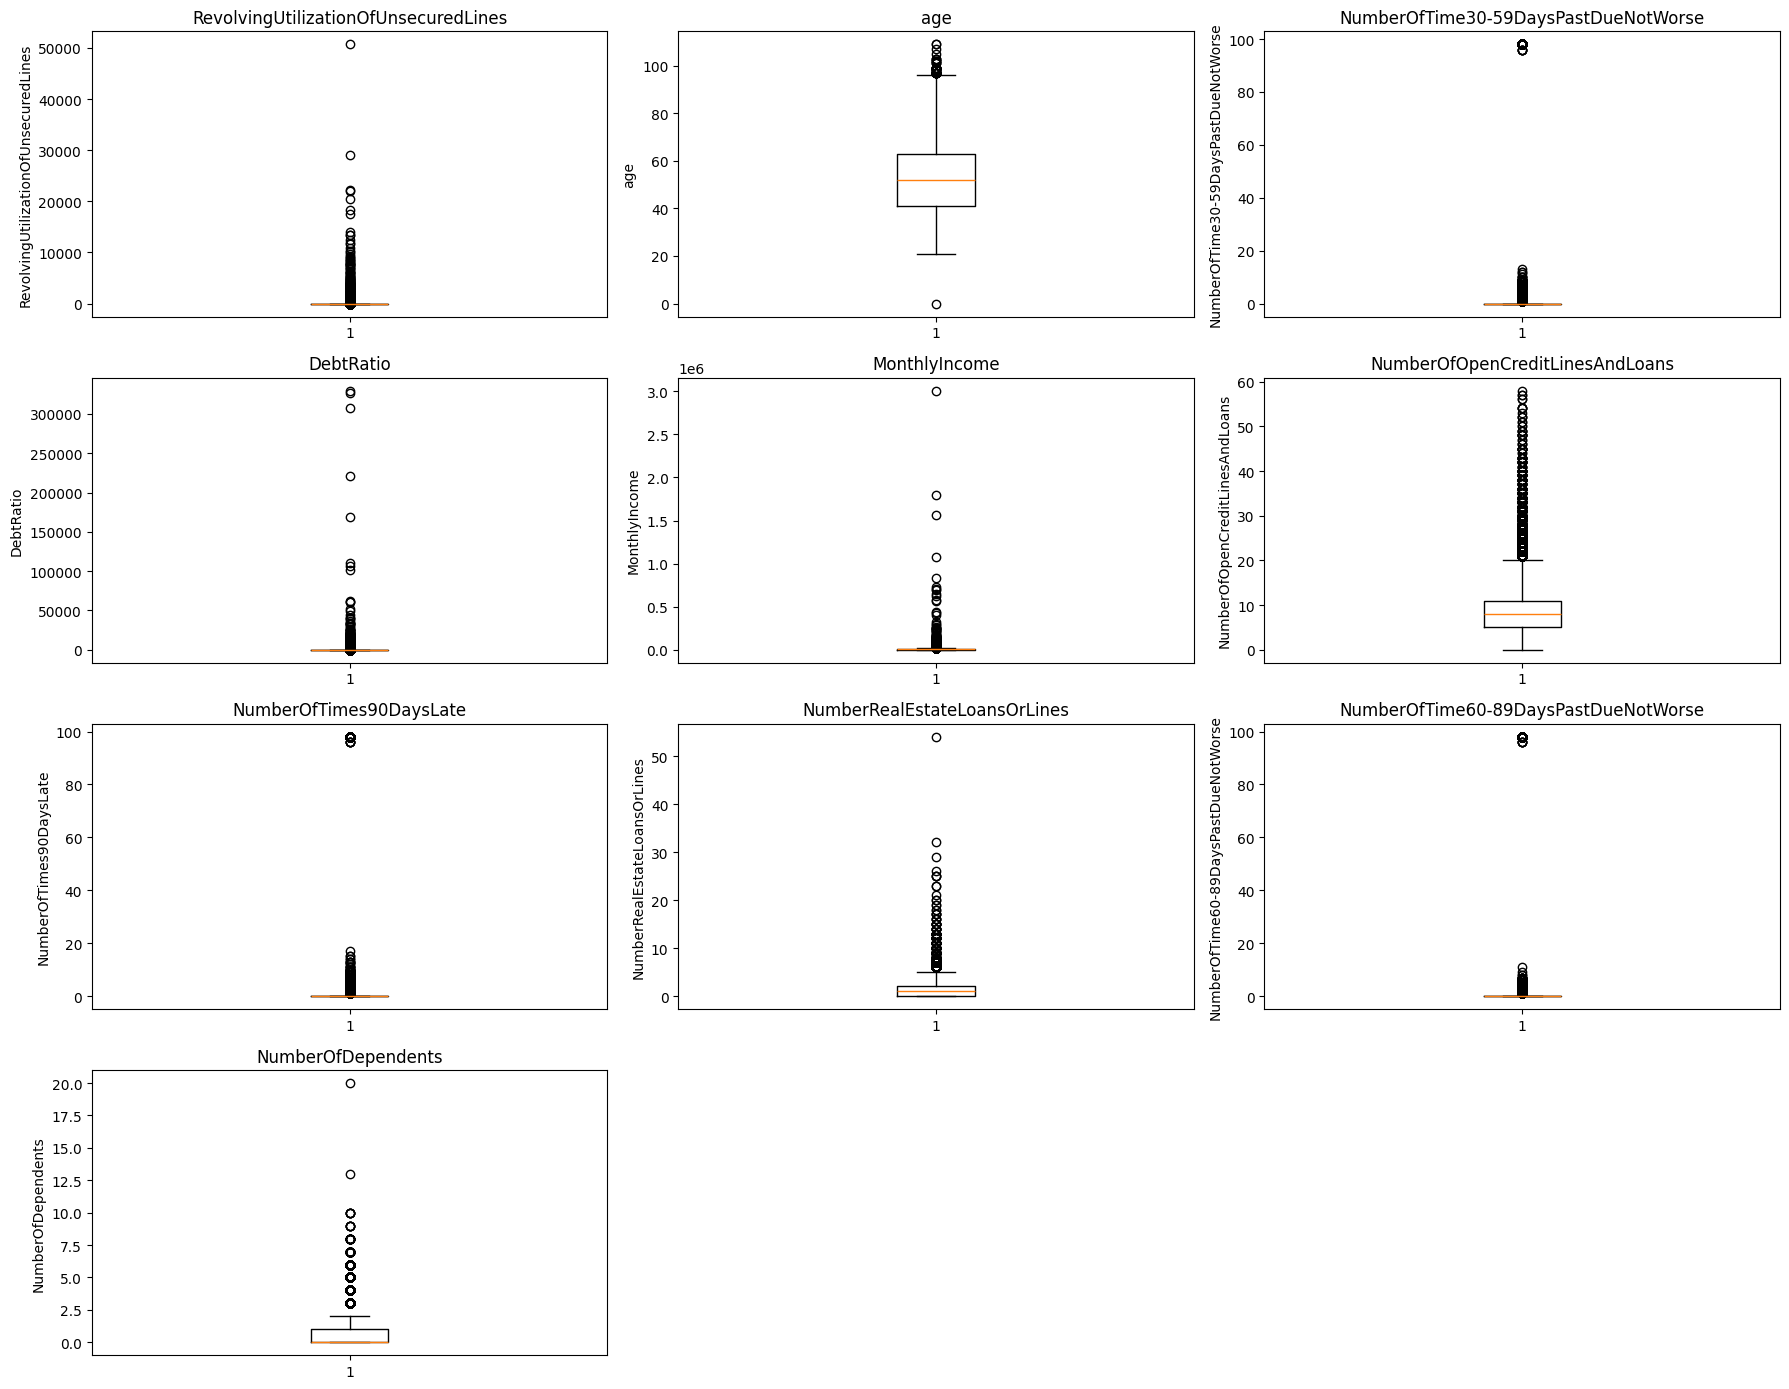

In [36]:
import matplotlib.pyplot as plt

num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    plt.boxplot(train_data[col].dropna(), vert=True)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Nhiều biến có outliers/giá trị bất thường: RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome, age

### Kết luận từ phân tích đơn biến
- Nhãn dữ liệu bị mất cân bằng nghiêm trọng
- Hầu hết các biến đều lệch phải, trừ biến age
- Các biến xuất hiện nhiều outliers